# Concatenate results from 3 metrics

In [1]:
import pandas as pd

In [2]:
df_tfidf = pd.read_parquet('./TF-IDF/df_1_1_cosim.parquet')
df_tfidf.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF_cosim
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381


In [3]:
df_SBERT = pd.read_parquet('./SBERT/df_SBERT_cosim.parquet')
df_SBERT.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,chunked_AI_essay,chunked_humanized_essay,SBERT_cosim
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,[the integration of social media into the live...,[the way social media has woven itself into th...,0.850309
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,[the integration of social media into the live...,[social media has become a big part of young p...,0.754118
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,[the integration of social media into the live...,[the penetration of social media into the live...,0.915031
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,[the integration of social media into the live...,[social media ' s introduction into young peop...,0.930350
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,[the integration of social media into the live...,[Young people face a harmful environment throu...,0.850842


In [4]:
df_Nemotron = pd.read_parquet('./Llama_Nemotron_8b/df_Nemotron_cosim.parquet')
df_Nemotron.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_embedding,humanized_embedding,Nemotron_cosim
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,"[-0.007160546, -0.0003037693, -0.006392883, -0...","[-0.013025091, 0.0053213853, -0.01455603, -0.0...",0.907571
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,"[-0.007160546, -0.0003037693, -0.006392883, -0...","[-0.0066511543, 0.0019869793, -0.01906914, 0.0...",0.848066
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,"[-0.007160546, -0.0003037693, -0.006392883, -0...","[-0.004271907, -0.0030379181, -0.008151056, -0...",0.934771
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,"[-0.007160546, -0.0003037693, -0.006392883, -0...","[-0.00037478175, -0.0058011212, -0.008065408, ...",0.936948
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,"[-0.007160546, -0.0003037693, -0.006392883, -0...","[0.009485136, 0.0016668144, -0.011159632, 0.01...",0.844359


# Join table

In [5]:
# merge with column topic, length, AI_model, humanizer, AI_essay, humanized_essay and get cosim from each
merge_columns = ['topic', 'length', 'AI_model', 'humanizer', 'AI_essay', 'humanized_essay']
df_results = df_tfidf.merge(df_SBERT[merge_columns + ['SBERT_cosim']], on=merge_columns)
df_results = df_results.merge(df_Nemotron[merge_columns + ['Nemotron_cosim']], on=merge_columns)
df_results.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF_cosim,SBERT_cosim,Nemotron_cosim
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359


In [6]:
# filter out the outliers, remove index 161
df_results_filtered = df_results.drop(index=161)
df_results_filtered

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF_cosim,SBERT_cosim,Nemotron_cosim
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359
...,...,...,...,...,...,...,...,...,...
175,5,3,gpt4.0,Grammarly,Childhood is often remembered through the lens...,Childhood is frequently recalled as a period m...,0.710457,0.885729,0.976475
176,5,3,gpt4.0,HumanizeAI,Childhood is often remembered through the lens...,Childhood is often remembered as a realm of si...,0.672900,0.875838,0.929074
177,5,3,gpt4.0,Quillbot,Childhood is often remembered through the lens...,Childhood is frequently viewed through the pri...,0.689754,0.913983,0.950578
178,5,3,gpt4.0,UndetectableAI,Childhood is often remembered through the lens...,People tend to recall their childhood through ...,0.601803,0.853232,0.918383


# Visualization

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
custom_palette = sns.color_palette(['#a8bccb', '#5e7c93', '#293742'])
sns.set_palette(custom_palette)

In [9]:
df_results_filtered.rename(columns={'TF-IDF_cosim': 'TF-IDF', 'SBERT_cosim': 'SBERT', 'Nemotron_cosim': 'Nemotron'}, inplace=True)
# change length 1 to Short, 2 to Medium, 3 to Long
df_results_filtered['length'] = df_results_filtered['length'].map({1: 'Short', 2: 'Medium', 3: 'Long'})
df_results_filtered

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
0,1,Short,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,Short,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,Short,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,Short,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,Short,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359
...,...,...,...,...,...,...,...,...,...
175,5,Long,gpt4.0,Grammarly,Childhood is often remembered through the lens...,Childhood is frequently recalled as a period m...,0.710457,0.885729,0.976475
176,5,Long,gpt4.0,HumanizeAI,Childhood is often remembered through the lens...,Childhood is often remembered as a realm of si...,0.672900,0.875838,0.929074
177,5,Long,gpt4.0,Quillbot,Childhood is often remembered through the lens...,Childhood is frequently viewed through the pri...,0.689754,0.913983,0.950578
178,5,Long,gpt4.0,UndetectableAI,Childhood is often remembered through the lens...,People tend to recall their childhood through ...,0.601803,0.853232,0.918383


## TF-IDF

In [10]:
df_tfidf_humanizer = df_results_filtered[['humanizer', 'TF-IDF']].groupby('humanizer').mean().reset_index()
df_tfidf_humanizer.sort_values(by='TF-IDF', inplace=True)
df_tfidf_humanizer

,humanizer,TF-IDF
4,UndetectableAI,0.593840
5,writehuman.ai,0.644740
2,HumanizeAI,0.648192
1,Grammarly,0.657888
0,AIHumanizer,0.662138
3,Quillbot,0.670495


In [11]:
df_tfidf_humanizer_length = df_results_filtered[['humanizer', 'length', 'TF-IDF']].groupby(['humanizer', 'length']).mean().reset_index()
df_tfidf_humanizer_length

,humanizer,length,TF-IDF
0,AIHumanizer,Long,0.747805
1,AIHumanizer,Medium,0.671241
2,AIHumanizer,Short,0.567367
3,Grammarly,Long,0.679286
4,Grammarly,Medium,0.645125
5,Grammarly,Short,0.649253
6,HumanizeAI,Long,0.737723
7,HumanizeAI,Medium,0.647358
8,HumanizeAI,Short,0.559495
9,Quillbot,Long,0.744594


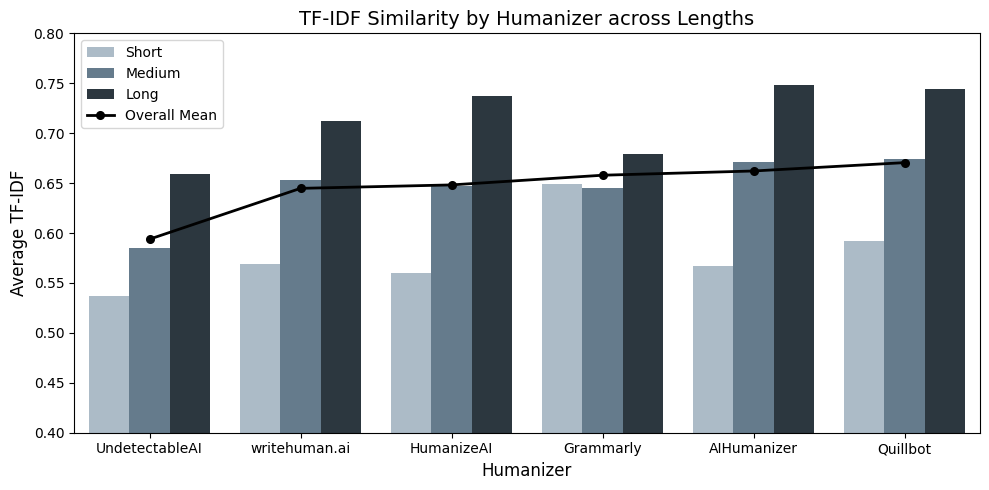

In [33]:
sorted_humanizer_order = df_tfidf_humanizer['humanizer'].tolist()
hue_order = ['Short', 'Medium', 'Long']

from matplotlib.lines import Line2D
plt.figure(figsize=(10, 5))

#bar plot
ax = sns.barplot(data=df_tfidf_humanizer_length, x='humanizer', y='TF-IDF', hue='length', order=sorted_humanizer_order, hue_order=hue_order)

#line plot of mean
sns.pointplot(data=df_tfidf_humanizer, x='humanizer', y='TF-IDF', color='black', markers='o', label='Overall Mean', order=sorted_humanizer_order, linewidth=2)

plt.title('TF-IDF Similarity by Humanizer across Lengths', fontsize=14)
plt.xlabel('Humanizer', fontsize=12)
plt.ylabel('Average TF-IDF', fontsize=12)

# handles, labels = ax.get_legend_handles_labels()

# handles.append(Line2D([0], [0], color='black', marker='_', linestyle='-', markersize=3, linewidth=0.4))
# ax.legend(handles=handles, labels=labels, title='Essay Length / Mean', bbox_to_anchor=(1, 1), loc='upper left')
#set y-axis limit
plt.ylim(0.4, 0.8)
plt.tight_layout()
plt.show()

# SBERT

In [15]:
df_sbert_humanizer = df_results_filtered[['humanizer', 'SBERT']].groupby('humanizer').mean().reset_index()
df_sbert_humanizer.sort_values(by='SBERT', inplace=True)
df_sbert_humanizer

,humanizer,SBERT
4,UndetectableAI,0.839513
1,Grammarly,0.854580
5,writehuman.ai,0.859876
2,HumanizeAI,0.872343
0,AIHumanizer,0.880143
3,Quillbot,0.912473


In [16]:
df_sbert_humanizer_length = df_results_filtered[['humanizer', 'length', 'SBERT']].groupby(['humanizer', 'length']).mean().reset_index()
df_sbert_humanizer_length

,humanizer,length,SBERT
0,AIHumanizer,Long,0.879796
1,AIHumanizer,Medium,0.882853
2,AIHumanizer,Short,0.877779
3,Grammarly,Long,0.839034
4,Grammarly,Medium,0.851462
5,Grammarly,Short,0.873244
6,HumanizeAI,Long,0.871362
7,HumanizeAI,Medium,0.877677
8,HumanizeAI,Short,0.867990
9,Quillbot,Long,0.913641


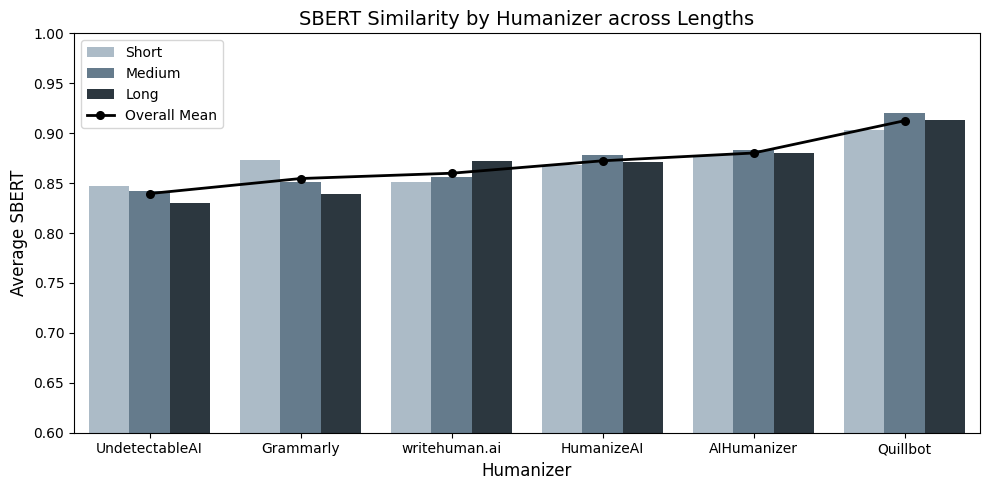

In [32]:
sorted_humanizer_order = df_sbert_humanizer['humanizer'].tolist()
hue_order = ['Short', 'Medium', 'Long']
from matplotlib.lines import Line2D
plt.figure(figsize=(10,5))

#bar plot
ax = sns.barplot(data=df_sbert_humanizer_length, x='humanizer', y='SBERT', hue='length', order=sorted_humanizer_order, hue_order=hue_order)

#line plot of mean
sns.pointplot(data=df_sbert_humanizer, x='humanizer', y='SBERT', color='black', markers='o', label='Overall Mean', order=sorted_humanizer_order, linewidth=2)

plt.title('SBERT Similarity by Humanizer across Lengths', fontsize=14)
plt.xlabel('Humanizer', fontsize=12)
plt.ylabel('Average SBERT', fontsize=12)

# handles, labels = ax.get_legend_handles_labels()

# handles.append(Line2D([0], [0], color='black', marker='_', linestyle='-', markersize=3, linewidth=0.4))
# ax.legend(handles=handles, labels=labels, title='Essay Length / Mean', bbox_to_anchor=(1, 1), loc='upper left')
#set y-axis limit
plt.ylim(0.60, 1.0)

plt.tight_layout()
plt.show()

# Nemotron

In [20]:
df_nemotron_humanizer = df_results_filtered[['humanizer', 'Nemotron']].groupby('humanizer').mean().reset_index()
df_nemotron_humanizer.sort_values(by='Nemotron', inplace=True)
df_nemotron_humanizer

,humanizer,Nemotron
5,writehuman.ai,0.894185
4,UndetectableAI,0.896103
2,HumanizeAI,0.927303
1,Grammarly,0.935124
0,AIHumanizer,0.953153
3,Quillbot,0.955062


In [21]:
df_nemotron_humanizer_length = df_results_filtered[['humanizer', 'length', 'Nemotron']].groupby(['humanizer', 'length']).mean().reset_index()
df_nemotron_humanizer_length

,humanizer,length,Nemotron
0,AIHumanizer,Long,0.960100
1,AIHumanizer,Medium,0.954717
2,AIHumanizer,Short,0.944642
3,Grammarly,Long,0.925990
4,Grammarly,Medium,0.937441
5,Grammarly,Short,0.941940
6,HumanizeAI,Long,0.941691
7,HumanizeAI,Medium,0.919458
8,HumanizeAI,Short,0.920761
9,Quillbot,Long,0.961390


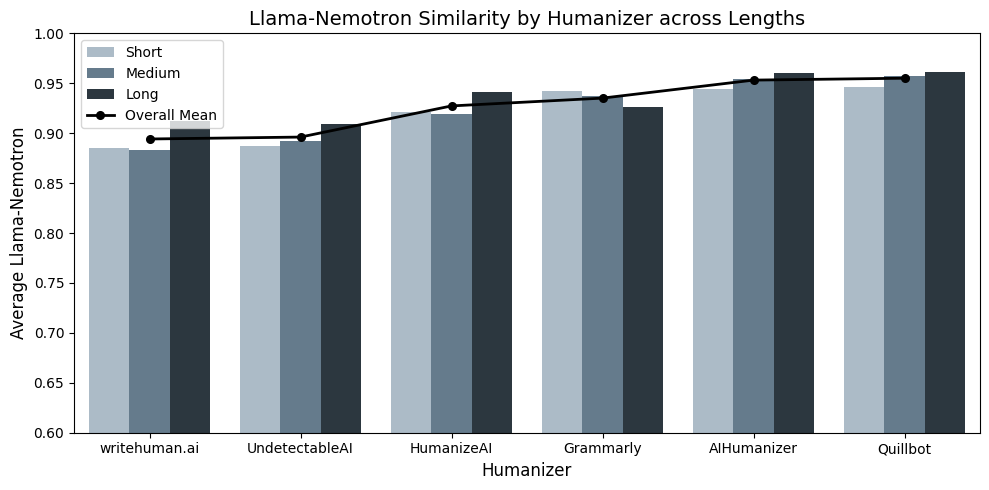

In [31]:
sorted_humanizer_order = df_nemotron_humanizer['humanizer'].tolist()
hue_order = ['Short', 'Medium', 'Long']
from matplotlib.lines import Line2D
plt.figure(figsize=(10,5))

#bar plot
ax = sns.barplot(data=df_nemotron_humanizer_length, x='humanizer', y='Nemotron', hue='length', order=sorted_humanizer_order, hue_order=hue_order)

#line plot of mean
sns.pointplot(data=df_nemotron_humanizer, x='humanizer', y='Nemotron', color='black', markers='o', label='Overall Mean', order=sorted_humanizer_order, linewidth=2)

plt.title('Llama-Nemotron Similarity by Humanizer across Lengths', fontsize=14)
plt.xlabel('Humanizer', fontsize=12)
plt.ylabel('Average Llama-Nemotron', fontsize=12)

# handles, labels = ax.get_legend_handles_labels()

# handles.append(Line2D([0], [0], color='black', marker='_', linestyle='-', markersize=3, linewidth=0.4))
# ax.legend(handles=handles, labels=labels, title='Essay Length / Mean', bbox_to_anchor=(1, 1), loc='upper left')
#set y-axis limit
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

# Analysis

In [22]:
df_results_filtered

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
0,1,Short,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571
1,1,Short,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066
2,1,Short,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,0.502740,0.915031,0.934771
3,1,Short,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,0.505379,0.930350,0.936948
4,1,Short,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,0.428381,0.850842,0.844359
...,...,...,...,...,...,...,...,...,...
175,5,Long,gpt4.0,Grammarly,Childhood is often remembered through the lens...,Childhood is frequently recalled as a period m...,0.710457,0.885729,0.976475
176,5,Long,gpt4.0,HumanizeAI,Childhood is often remembered through the lens...,Childhood is often remembered as a realm of si...,0.672900,0.875838,0.929074
177,5,Long,gpt4.0,Quillbot,Childhood is often remembered through the lens...,Childhood is frequently viewed through the pri...,0.689754,0.913983,0.950578
178,5,Long,gpt4.0,UndetectableAI,Childhood is often remembered through the lens...,People tend to recall their childhood through ...,0.601803,0.853232,0.918383


In [23]:
df_results_filtered.sort_values(by=['TF-IDF'], ascending=False)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
109,4,Short,gemini2.5pro,Grammarly,The rapid integration of artificial intelligen...,The rapid integration of artificial intelligen...,0.971951,0.957094,0.996634
139,4,Long,gpt4.0,Grammarly,As artificial intelligence (AI) continues to e...,As artificial intelligence (AI) evolves and be...,0.894781,0.912695,0.985271
71,2,Long,gpt4.0,writehuman.ai,Fixing a broken fan may seem like a daunting t...,For someone completely new to electrical repai...,0.848848,0.889887,0.926920
138,4,Long,gpt4.0,AIHumanizer,As artificial intelligence (AI) continues to e...,As artificial intelligence (AI) continues to e...,0.845429,0.919643,0.970577
56,2,Medium,gpt4.0,HumanizeAI,Fixing a broken fan may seem intimidating at f...,Repairing a broken fan might be intimidating a...,0.845129,0.922968,0.970262
...,...,...,...,...,...,...,...,...,...
147,5,Short,gemini2.5pro,Quillbot,"The unmistakable, frantic melody of its openin...","Its opening theme's distinctive, frantic melod...",0.395313,0.813032,0.957959
148,5,Short,gemini2.5pro,UndetectableAI,"The unmistakable, frantic melody of its openin...",The frantic opening theme of the show became t...,0.368960,0.821251,0.881741
5,1,Short,gemini2.5pro,writehuman.ai,The integration of social media into the lives...,There is an important and critical psychologic...,0.362553,0.790600,0.738423
0,1,Short,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,0.359997,0.850309,0.907571


In [24]:
df_results_filtered.sort_values(by=['SBERT'], ascending=False)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
109,4,Short,gemini2.5pro,Grammarly,The rapid integration of artificial intelligen...,The rapid integration of artificial intelligen...,0.971951,0.957094,0.996634
115,4,Short,gpt4.0,Grammarly,The rapid advancement of artificial intelligen...,The rapid advancement of artificial intelligen...,0.734144,0.952312,0.985651
30,1,Long,gpt4.0,AIHumanizer,"In recent years, social media has revolutioniz...","Over the past few years, social media has comp...",0.788937,0.950624,0.944096
15,1,Medium,gemini2.5pro,Quillbot,The pervasive integration of social media into...,One of the biggest sociological changes of the...,0.680631,0.947692,0.962973
45,2,Short,gpt4.0,Quillbot,Fixing a broken fan may seem like a complicate...,Although fixing a broken fan might seem like a...,0.705910,0.944052,0.969290
...,...,...,...,...,...,...,...,...,...
37,2,Short,gemini2.5pro,Grammarly,"A silent, stationary fan on a sweltering day c...",It’s frustrating when your fan stops working o...,0.609795,0.771078,0.868561
25,1,Long,gemini2.5pro,Grammarly,The integration of social media into the daily...,Social media is now a basic part of daily life...,0.468314,0.763770,0.918042
160,5,Medium,gemini2.5pro,UndetectableAI,The landscape of childhood is often painted wi...,Saturday morning cartoons bring their bright a...,0.473536,0.758247,0.882234
1,1,Short,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,0.336786,0.754118,0.848066


In [25]:
df_results_filtered.sort_values(by=['Nemotron'], ascending=False)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,TF-IDF,SBERT,Nemotron
109,4,Short,gemini2.5pro,Grammarly,The rapid integration of artificial intelligen...,The rapid integration of artificial intelligen...,0.971951,0.957094,0.996634
115,4,Short,gpt4.0,Grammarly,The rapid advancement of artificial intelligen...,The rapid advancement of artificial intelligen...,0.734144,0.952312,0.985651
139,4,Long,gpt4.0,Grammarly,As artificial intelligence (AI) continues to e...,As artificial intelligence (AI) evolves and be...,0.894781,0.912695,0.985271
168,5,Long,gemini2.5pro,AIHumanizer,The landscape of childhood is often painted wi...,Childhood often feels like a canvas splashed w...,0.801277,0.896681,0.983137
121,4,Medium,gemini2.5pro,Grammarly,Artificial intelligence is rapidly evolving fr...,Artificial intelligence is rapidly evolving fr...,0.799412,0.886711,0.982333
...,...,...,...,...,...,...,...,...,...
20,1,Medium,gpt4.0,HumanizeAI,"In the digital age, social media has become an...",A social media platform has every LoL go and c...,0.559605,0.865169,0.832259
167,5,Medium,gpt4.0,writehuman.ai,"Growing up, few things held as much joy and ex...",Waking up on Saturday mornings this way was pu...,0.518256,0.845826,0.820331
119,4,Short,gpt4.0,writehuman.ai,The rapid advancement of artificial intelligen...,With the rapid development of artificial intel...,0.590319,0.816771,0.801929
97,3,Long,gemini2.5pro,Grammarly,J.K. Rowling's Harry Potter and the Philosophe...,J.K. Rowling’s Harry Potter and the Philosophe...,0.456801,0.721391,0.755083


In [26]:
df_results_filtered.to_excel('essay_similarity_results.xlsx', index=False)

In [27]:
# for each length and humanizer, get the mean of each model
df_length_humanizer = df_results_filtered.groupby(['length', 'humanizer'])[['TF-IDF', 'SBERT', 'Nemotron']].mean().reset_index()
df_length_humanizer

,length,humanizer,TF-IDF,SBERT,Nemotron
0,Long,AIHumanizer,0.747805,0.879796,0.960100
1,Long,Grammarly,0.679286,0.839034,0.925990
2,Long,HumanizeAI,0.737723,0.871362,0.941691
3,Long,Quillbot,0.744594,0.913641,0.961390
4,Long,UndetectableAI,0.659438,0.830079,0.909529
5,Long,writehuman.ai,0.712549,0.872335,0.912675
6,Medium,AIHumanizer,0.671241,0.882853,0.954717
7,Medium,Grammarly,0.645125,0.851462,0.937441
8,Medium,HumanizeAI,0.647358,0.877677,0.919458
9,Medium,Quillbot,0.674524,0.920445,0.957127


In [78]:
df_humanizer = df_results_filtered.groupby(['humanizer'])[['TF-IDF', 'SBERT', 'Nemotron']].mean().reset_index()
df_humanizer

,humanizer,TF-IDF,SBERT,Nemotron
0,AIHumanizer,0.662138,0.880143,0.953153
1,Grammarly,0.657888,0.854580,0.935124
2,HumanizeAI,0.648192,0.872343,0.927303
3,Quillbot,0.670495,0.912473,0.955062
4,UndetectableAI,0.593840,0.839513,0.896103
5,writehuman.ai,0.644740,0.859876,0.894185


In [79]:
# save this to second sheet of "essay_similarity_results.xlsx"
with pd.ExcelWriter('essay_similarity_results.xlsx', mode='a', engine='openpyxl') as writer:
    df_length_humanizer.to_excel(writer, sheet_name='Groupby_Length_Humanizer', index=False)
    df_humanizer.to_excel(writer, sheet_name='Groupby_Humanizer', index=False)